In [ ]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#defining the data file
df = pd.read_csv('/content/advertising.csv')

In [ ]:
#shape of the data
df.shape

(200, 4)

In [ ]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
#Checking for null values
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


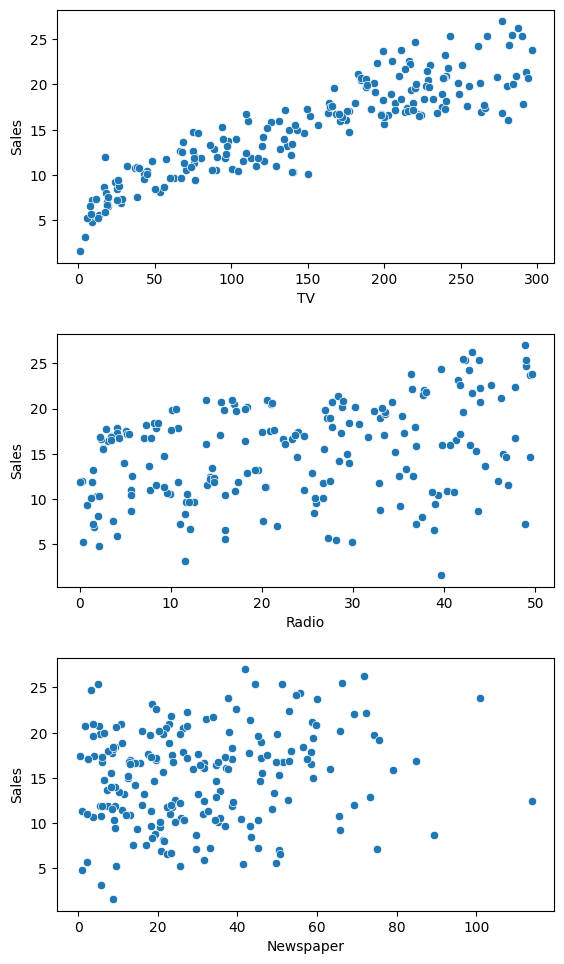

In [ ]:
fig , axs =plt.subplots(3,figsize=(6,10))

sns.scatterplot(x=df['TV'],y=df['Sales'], ax = axs[0])
sns.scatterplot(x=df['Radio'],y=df['Sales'], ax = axs[1])
sns.scatterplot(x=df['Newspaper'],y=df['Sales'], ax = axs[2])
plt.tight_layout(pad=2.0)
plt.show()

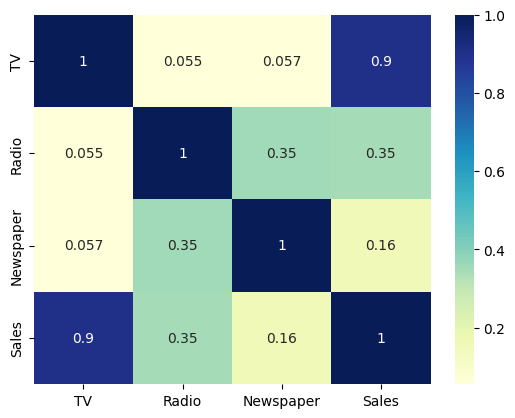

<Figure size 600x1000 with 0 Axes>

In [ ]:
sns.heatmap(df.corr(),annot=True,cmap='YlGnBu')
plt.figure(figsize=(6,10))
plt.show()

In [ ]:
#Dropping sales for training and making a target variable

X = df.drop('Sales',axis=1)
Y = df['Sales']

In [ ]:
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [ ]:

Y.head()

,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [ ]:
Y_train.head()

,Sales
79,11.0
197,14.8
38,10.1
24,9.7
122,16.6


In [ ]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Loading model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
#Model Evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

Y_pred = model.predict(X_test)
mae = mean_absolute_error(Y_test,Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test,Y_pred)

print(f"Mean Absolute Error:{mae}\nMean Squared Error:{mse}\nR2 Score:{r2}")

Mean Absolute Error:1.2748262109549349
Mean Squared Error:2.9077569102710927
R2 Score:0.9059011844150825


<Axes: xlabel='Sales'>

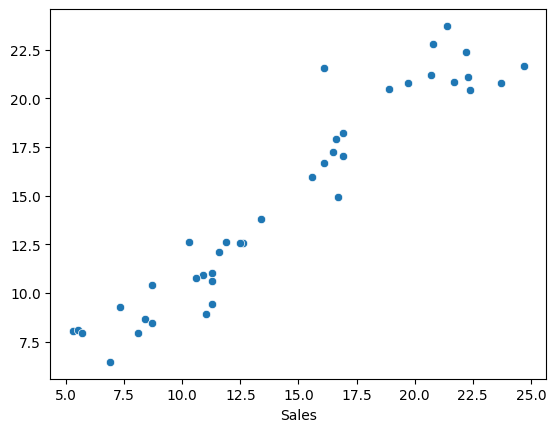

In [ ]:
sns.scatterplot(x=Y_test,y=Y_pred)

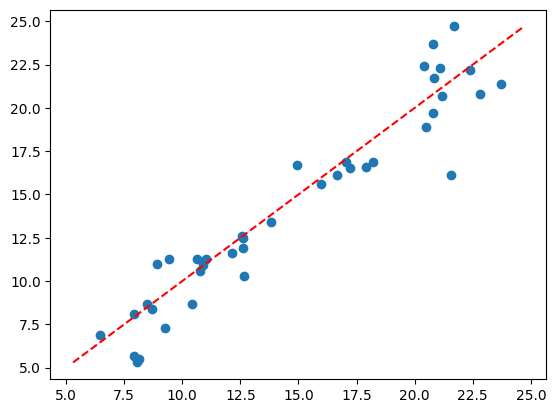

In [ ]:
plt.scatter(x=Y_pred, y=Y_test)
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],"r--")

In [ ]:
#Saving model
import joblib

joblib.dump(model,'sales_prediction.pkl')

['sales_prediction.pkl']

In [ ]:
from google.colab import files
files.download('sales_prediction.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>